In [1]:
%matplotlib widget

In [2]:
from pathlib import Path

import requests
from tqdm import tqdm
from sam2.build_sam import build_sam2
from sam2.automatic_mask_generator import SAM2ImagePredictor
import torch

checkpoint_path = Path("checkpoints/sam2.1_hiera_base_plus.pt")

if not checkpoint_path.exists():
    response = requests.get(
        "https://dl.fbaipublicfiles.com/segment_anything_2/092824/sam2.1_hiera_base_plus.pt",
        stream=True,
    )
    total = int(response.headers.get("content-length", 0))
    checkpoint_path.parent.mkdir(parents=True, exist_ok=True)
    with (
        open(checkpoint_path, "wb") as f,
        tqdm(
            total=total,
            unit="iB",
            unit_scale=True,
            unit_divisor=1024,
        ) as progress,
    ):
        for chunk in response.iter_content(chunk_size=1024):
            progress.update(f.write(chunk))

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
print(f"Device: {device}")

model = build_sam2(
    "configs/sam2.1/sam2.1_hiera_b+.yaml",
    checkpoint_path,
    device=device,
)
predictor = SAM2ImagePredictor(model)

Device: mps


In [3]:
import numpy as np
from scipy.ndimage import gaussian_filter


def invert_zebra(
    image: np.ndarray,
    mask: np.ndarray,
    sigma=15,
    chroma_strength=0.25,
):
    x = image.astype(np.float32) / 255

    L = 0.2126 * x[..., 0] + 0.7152 * x[..., 1] + 0.0722 * x[..., 2]
    m = mask.astype(np.float32)

    numerator = gaussian_filter(L * m, sigma=sigma)
    denominator = gaussian_filter(m, sigma=sigma)
    local_L = numerator / np.maximum(denominator, 1e-6)

    new_L = 2.0 * local_L - L
    new_L = np.clip(new_L, 0.0, 1.0)

    chroma = x - L[..., None]

    transformed = new_L[..., None] + chroma_strength * chroma
    transformed = np.clip(transformed, 0.0, 1.0)

    y = x.copy()
    y[mask] = transformed[mask]
    return (y * 255).astype(np.uint8)

[0.9862518 0.2624056 0.8284443]


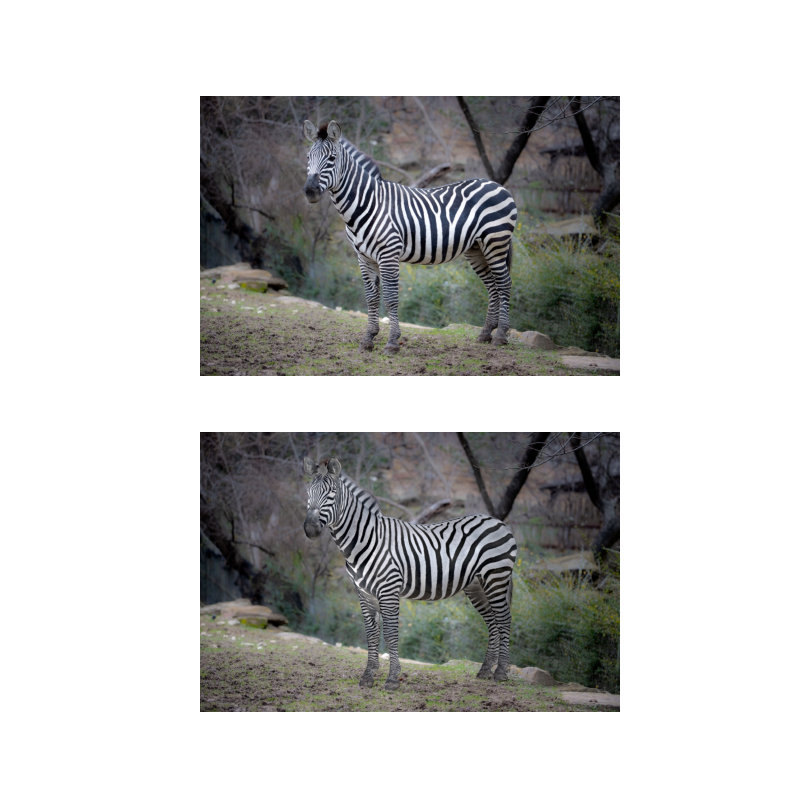

In [ ]:
import colorsys

from PIL import Image
from matplotlib import pyplot as plt
import numpy as np

IMAGE_PATH = Path("images/originals/photo-1548091654-7bfa962a7123.avif")

image = np.array(Image.open(IMAGE_PATH).convert("RGB"))

predictor.set_image(image)
masks, scores, _ = predictor.predict(
    point_coords=np.array([[image.shape[1] / 2, image.shape[0] / 2]]),
    point_labels=np.array([1]),
    multimask_output=True,
)
print(scores)

mask = masks[np.argmax(scores)]
assert np.count_nonzero(((0 < mask) & (mask < 1))) == 0
mask = mask != 0

inv_image = invert_zebra(
    image,
    mask,
    sigma=30 * image.shape[0] / 1780,
    chroma_strength=0.5,
)

fig, ax = plt.subplots(2, 1, figsize=(8, 8))
ax[0].imshow(image)
ax[1].imshow(inv_image)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets

from matplotlib.widgets import RectangleSelector
from IPython.display import display


class BoundingBoxWidget:
    def __init__(self, image, callback):
        self.original_image = np.asarray(image)
        self.image = self.original_image
        self.callback = callback
        self.bbox = None

        self.output = widgets.Output()

        with self.output:
            self.fig, self.ax = plt.subplots()
            self.im = self.ax.imshow(self.image)

            self.selector = RectangleSelector(
                self.ax,
                self._on_select,
                useblit=True,
                button=[1],
                minspanx=2,
                minspany=2,
                spancoords="pixels",
                interactive=True,
            )

            plt.show()

    def _on_select(self, eclick, erelease):
        x0, y0 = eclick.xdata, eclick.ydata
        x1, y1 = erelease.xdata, erelease.ydata

        if None in (x0, y0, x1, y1):
            return

        x0, x1 = sorted((x0, x1))
        y0, y1 = sorted((y0, y1))

        h, w = self.image.shape[:2]

        x0 = int(np.clip(round(x0), 0, w))
        x1 = int(np.clip(round(x1), 0, w))
        y0 = int(np.clip(round(y0), 0, h))
        y1 = int(np.clip(round(y1), 0, h))

        self.bbox = (x0, y0, x1, y1)

        new_image = self.callback(self.bbox)
        if new_image is not None:
            self.set_image(new_image)

    def set_image(self, image):
        self.image = np.asarray(image)

        self.im.set_data(self.image)

        h, w = self.image.shape[:2]

        self.ax.set_xlim(-0.5, w - 0.5)
        self.ax.set_ylim(h - 0.5, -0.5)

        self.fig.canvas.draw_idle()

    def display(self):
        display(self.output)

In [48]:
inv_image2 = inv_image


def callback(bbox):
    global inv_image2
    masks, scores, _ = predictor.predict(
        box=bbox,
        multimask_output=True,
    )

    eye_mask = masks[np.argmax(scores)]
    assert np.count_nonzero(((0 < eye_mask) & (eye_mask < 1))) == 0
    eye_mask = eye_mask != 0

    inv_image2 = inv_image.copy()
    inv_image2[eye_mask] = image[eye_mask]
    return inv_image2


viewer = BoundingBoxWidget(inv_image, callback)
viewer.display()

Output()

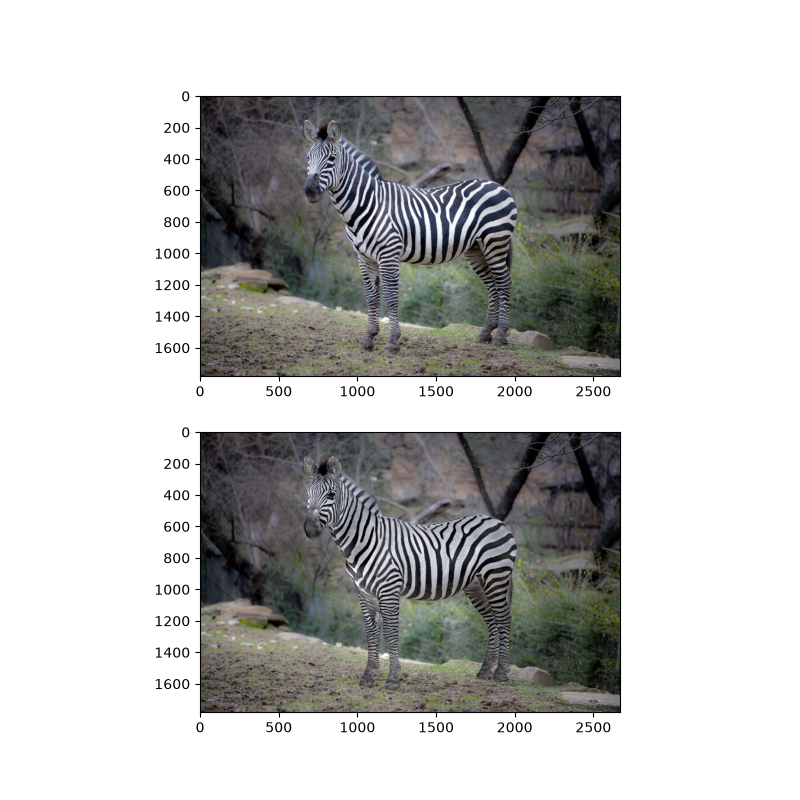

In [49]:
inv_image = inv_image2

fig, ax = plt.subplots(2, 1, figsize=(8, 8))
ax[0].imshow(image)
ax[1].imshow(inv_image)

In [50]:
import random
import string

random.seed(hash(IMAGE_PATH.name))
key = "".join([random.choice(string.ascii_letters + string.digits) for _ in range(8)])

images = [
    (Path(f"images/light/{key}.jpg"), image),
    (Path(f"images/dark/{key}.jpg"), inv_image2),
]
for path, img in images:
    path.parent.mkdir(parents=True, exist_ok=True)
    Image.fromarray(img).save(path)
    print("Saved:", path)

Saved: images/light/8eHsKarf.jpg
Saved: images/dark/8eHsKarf.jpg
